بسم الله

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate

# إعدادات العرض
sns.set(style='whitegrid', palette='muted', color_codes=True)

# النمذجة التنبؤية
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# تثبيت العشوائية
import random
random.seed(42)
np.random.seed(42)

# مكتبة الإحصاء والتحذيرات
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
# محاولة القراءة بترميز مختلف

In [2]:
charging = pd.read_csv("/kaggle/input/global-ev-charging-stations/charging_stations_2025_world.csv")
country = pd.read_csv("/kaggle/input/global-ev-charging-stations/country_summary_2025.csv")
ev_models = pd.read_csv("/kaggle/input/global-ev-charging-stations/ev_models_2025.csv")
world = pd.read_csv("/kaggle/input/global-ev-charging-stations/world_summary_2025.csv")

In [3]:
def summarize(df, name):
    
    print(f"=== {name} ===")
    
    print("Shape:", df.shape, "\n")
    
    print("Info:")
    df.info()
    print("\n")
    
    print("Describe:")
    display(df.describe(include="all").transpose())
    print("\n")
    
    print("Head:")
    display(df.head())
    print("\n" + "="*60 + "\n")

# --- Summaries ---
summarize(charging, "Charging Stations")
summarize(country, "Countries")
summarize(ev_models, "EV Models")
summarize(world, "World Summary")

=== Charging Stations ===
Shape: (242417, 11) 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            220228 non-null  object 
 3   country_code    242416 non-null  object 
 4   state_province  172419 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,242417.0,NaN,NaN,NaN,204039.926519,101789.186799,2389.0,122882.0,208085.0,280795.0,460650.0
name,242417,225282,Shell Recharge/Ubitricity,1166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,220228,41815,London,7665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_code,242416,120,US,82138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_province,172419,5988,CA,17528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,242417.0,NaN,NaN,NaN,43.253894,12.692335,-55.811599,38.859333,44.414623,51.41389,81.736061
longitude,242417.0,NaN,NaN,NaN,-32.07416,57.652645,-164.848855,-81.644018,-2.867264,7.883693,178.369254
ports,242417.0,NaN,NaN,NaN,1.959277,3.931007,-4.0,1.0,1.0,2.0,503.0
power_kw,237757.0,NaN,NaN,NaN,35.253735,2051.557432,0.0,3.7,11.0,22.0,1000000.0
power_class,242417,6,AC_L1_(<7.5kW),107144,NaN,NaN,NaN,NaN,NaN,NaN,NaN




Head:


,id,name,city,country_code,state_province,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,AD,NaN,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,AD,NaN,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,NaN,AD,NaN,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,NaN,AD,NaN,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,NaN,AD,NaN,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False




=== Countries ===
Shape: (122, 2) 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  121 non-null    object
 1   stations      122 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ KB


Describe:


...

,make,model,market_regions,powertrain,first_year,body_style,origin_country
0,Tesla,Model S,Global (US/EU/UK/ME),BEV,2012,Sedan,US
1,Tesla,Model 3,Global (US/EU/UK/ME/CN),BEV,2017,Sedan,US
2,Tesla,Model X,Global (US/EU/UK/ME),BEV,2015,SUV,US
3,Tesla,Model Y,Global (US/EU/UK/ME/CN),BEV,2020,SUV,US
4,Tesla,Cybertruck,US (limited),BEV,2023,Pickup,US




=== World Summary ===
Shape: (122, 4) 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_code      121 non-null    object 
 1   country           122 non-null    object 
 2   count             122 non-null    int64  
 3   max_power_kw_max  118 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_code,121,121,US,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,122,122,United States,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count,122.0,NaN,NaN,NaN,2035.204918,8616.963391,1.0,5.25,57.0,564.0,83821.0
max_power_kw_max,118.0,NaN,NaN,NaN,8710.432203,92035.801103,7.0,72.75,180.0,357.5,1000000.0




Head:


,country_code,country,count,max_power_kw_max
0,US,United States,83821,600.0
1,GB,United Kingdom,27437,560.0
2,DE,Germany,24465,400.0
3,CA,Canada,18203,400.0
4,ES,Spain,17864,1000.0


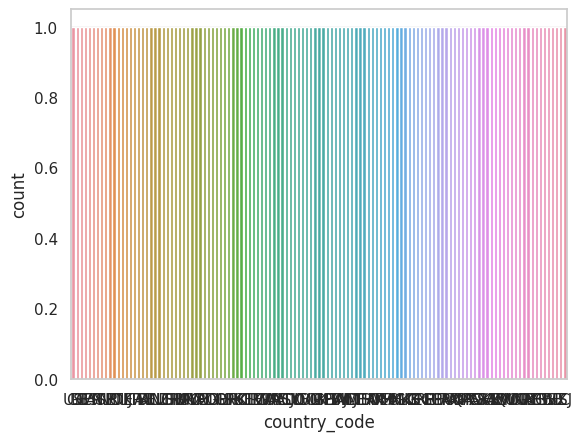

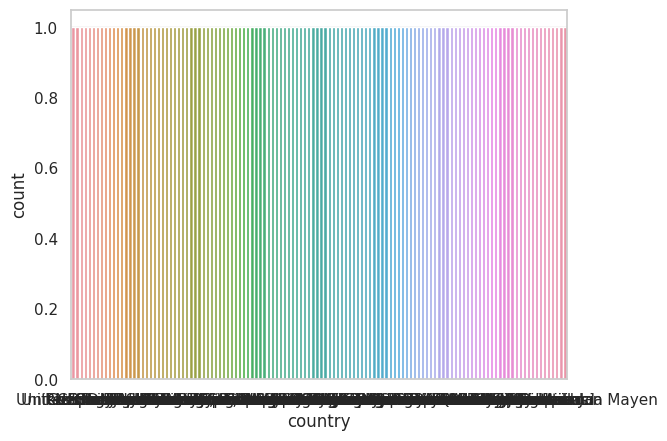

In [4]:
for col in world:
    if world[col].dtype == 'O':
        sns.countplot(x=col,data=world)
        plt.show()